In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k Dataset (1).csv',
 'placement_predict_50k_adjusted.csv.csv',
 'age_insurance.csv',
 '2520030358 _Experiment 4.ipynb',
 'simple_placement_dataset.csv',
 'Experiment5_2520030358.ipynb']

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Columns: ['StudentID', 'CGPA', 'Internships', 'Projects', 'AptitudeTestScore', 'CommunicationSkill', 'Placed']

Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10


Saved tree image as decision_tree.png


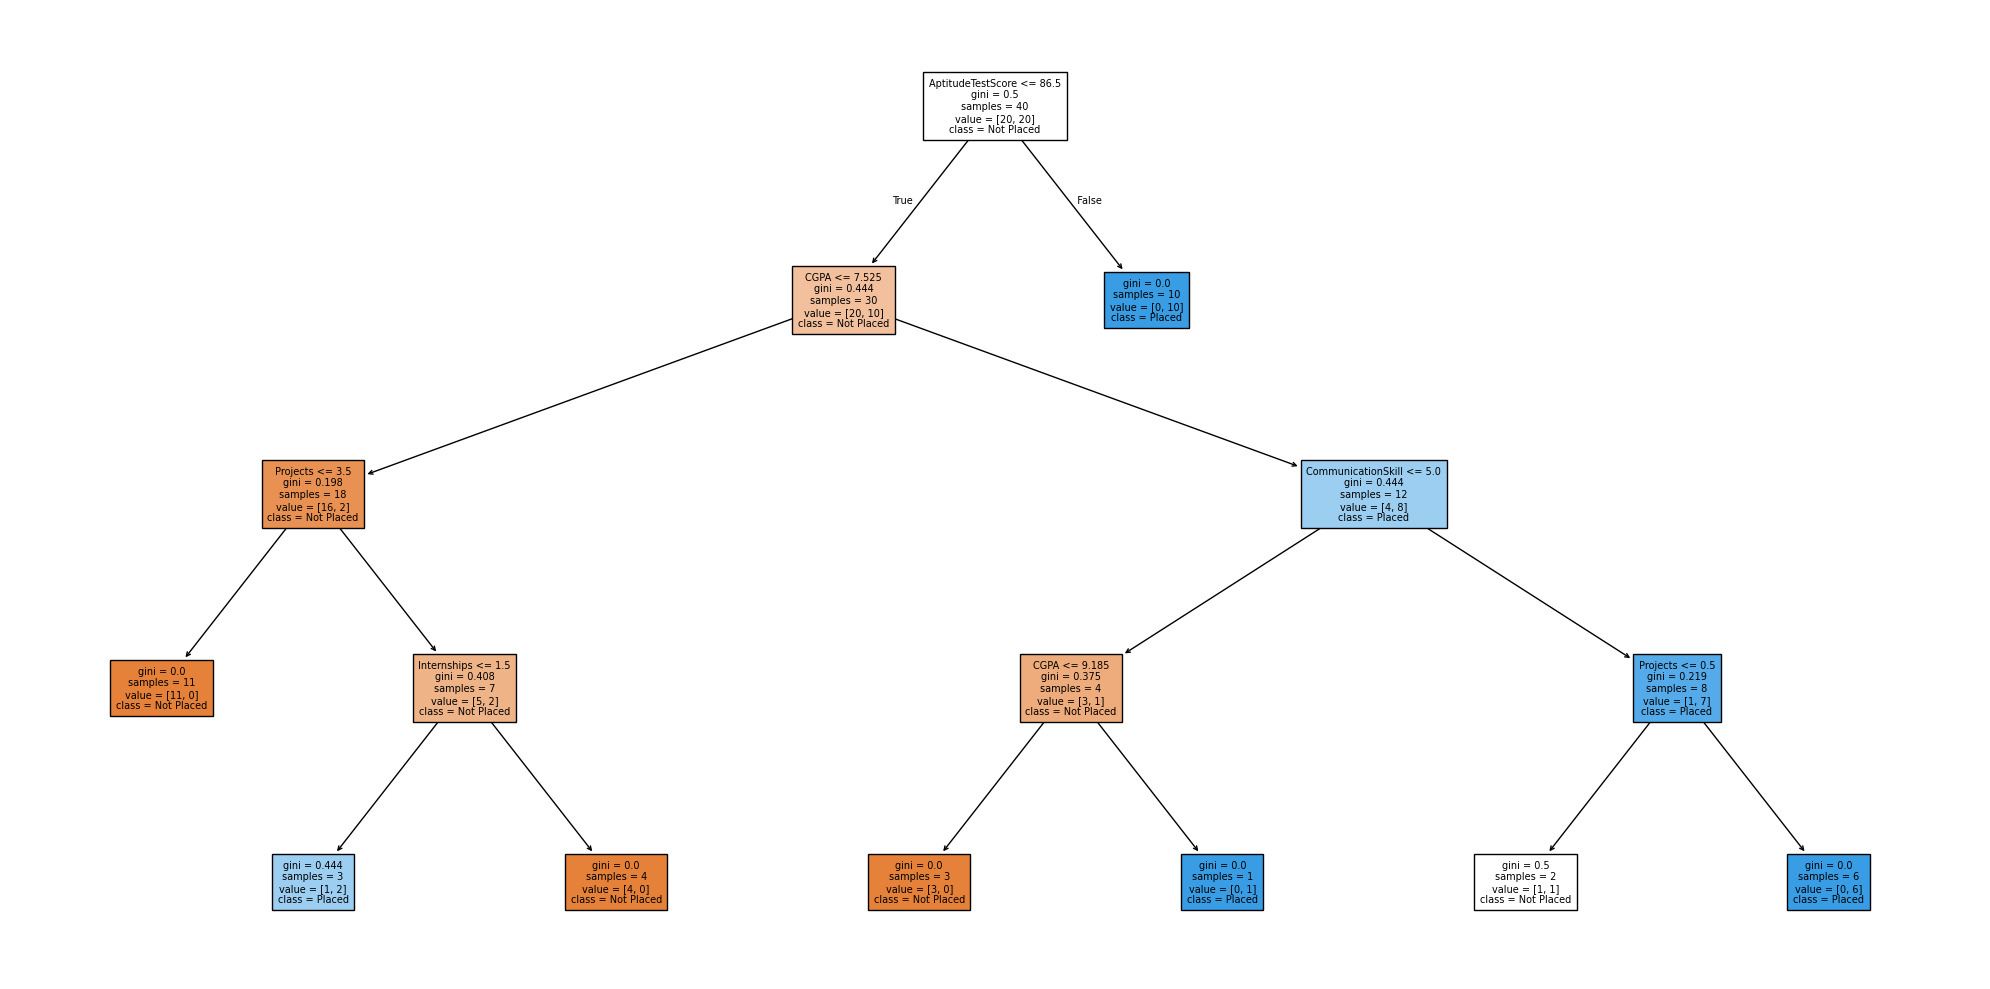

In [7]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/simple_placement_dataset.csv')

# Display dataset columns
print("Columns:", df.columns.tolist())

# Handle missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove StudentID because it is only an identifier
df = df.drop(columns=['StudentID'])

# No get_dummies() needed because the remaining input columns are numerical

# Separate features and target
X = df.drop(columns=['Placed'])
y = df['Placed']

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Decision Tree model
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()

# Save tree image
plt.savefig('decision_tree.png', dpi=150)

print("\nSaved tree image as decision_tree.png")